#Collecte de données

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


In [2]:
import os

# Liste les fichiers à la racine du dataset
print("Fichiers disponibles :", os.listdir(path))

# Vérifie s'il y a des sous-dossiers (souvent part_1 et part_2)
for item in os.listdir(path):
    if os.path.isdir(os.path.join(path, item)):
        print(f"Sous-dossier trouvé : {item} (contient {len(os.listdir(os.path.join(path, item)))} fichiers)")

Fichiers disponibles : ['hmnist_8_8_RGB.csv', 'hmnist_28_28_RGB.csv', 'HAM10000_images_part_1', 'ham10000_images_part_1', 'hmnist_8_8_L.csv', 'HAM10000_images_part_2', 'ham10000_images_part_2', 'hmnist_28_28_L.csv', 'HAM10000_metadata.csv']
Sous-dossier trouvé : HAM10000_images_part_1 (contient 5000 fichiers)
Sous-dossier trouvé : ham10000_images_part_1 (contient 5000 fichiers)
Sous-dossier trouvé : HAM10000_images_part_2 (contient 5015 fichiers)
Sous-dossier trouvé : ham10000_images_part_2 (contient 5015 fichiers)


In [3]:
import pandas as pd
import os
from glob import glob

# 1. Charger les métadonnées
df = pd.read_csv(os.path.join(path, 'HAM10000_metadata.csv'))

# 2. Créer un dictionnaire de tous les chemins d'images (.jpg)
# On cherche dans tous les sous-dossiers de 'path'
image_path_dict = {os.path.basename(x).replace('.jpg', ''): x
                   for x in glob(os.path.join(path, '*', '*.jpg'))}

# 3. Ajouter le chemin complet au DataFrame
df['path'] = df['image_id'].map(image_path_dict)

# 4. Créer la cible binaire (pour simplifier l'IA classique aujourd'hui)
# mel = mélanome (malin), le reste = bénin
df['target'] = df['dx'].apply(lambda x: 'malin' if x in ('mel', 'akiec', 'bcc') else 'benin')

# Vérification
print(f"Total images trouvées : {len(image_path_dict)}")
print(df[['image_id', 'target', 'path']].head())

Total images trouvées : 10015
       image_id target                                               path
0  ISIC_0027419  benin  /kaggle/input/skin-cancer-mnist-ham10000/ham10...
1  ISIC_0025030  benin  /kaggle/input/skin-cancer-mnist-ham10000/ham10...
2  ISIC_0026769  benin  /kaggle/input/skin-cancer-mnist-ham10000/ham10...
3  ISIC_0025661  benin  /kaggle/input/skin-cancer-mnist-ham10000/ham10...
4  ISIC_0031633  benin  /kaggle/input/skin-cancer-mnist-ham10000/ham10...


In [4]:
df["target"].value_counts()

,count
target,
benin,8061
malin,1954


#Normalisation

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

# --- A. ON DÉCOUPE LES DONNÉES (80% pour apprendre, 20% pour tester) ---
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['target'])

# --- B. ON PRÉPARE LES IMAGES (Redimensionnement et Normalisation) ---
datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_dataframe(
    train_df, x_col='path', y_col='target',
    target_size=(128, 128), batch_size=32, class_mode='binary'
)

test_gen = datagen.flow_from_dataframe(
    test_df, x_col='path', y_col='target',
    target_size=(128, 128), batch_size=32, class_mode='binary', shuffle=False
)

Found 8012 validated image filenames belonging to 2 classes.
Found 2003 validated image filenames belonging to 2 classes.


In [27]:
test_df.loc[[9786], ["path"]]

,path
9786,/kaggle/input/skin-cancer-mnist-ham10000/ham10...


In [20]:
test_df.loc[["image_id", "path"]]

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,target
2782,HAM_0005971,ISIC_0029539,bcc,histo,40.0,male,back,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,malin
8740,HAM_0000347,ISIC_0029665,nv,histo,45.0,male,lower extremity,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,benin
7012,HAM_0002323,ISIC_0031001,nv,histo,45.0,male,back,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,benin
9786,HAM_0002232,ISIC_0025825,akiec,histo,80.0,female,face,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,malin
5507,HAM_0005520,ISIC_0031255,nv,follow_up,65.0,male,back,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,benin
...,...,...,...,...,...,...,...,...,...
2722,HAM_0004662,ISIC_0027531,bcc,histo,65.0,male,lower extremity,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,malin
6129,HAM_0000570,ISIC_0027404,nv,follow_up,35.0,male,abdomen,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,benin
2039,HAM_0000856,ISIC_0028537,mel,histo,35.0,male,back,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,malin
8184,HAM_0005840,ISIC_0032260,nv,histo,45.0,female,chest,/kaggle/input/skin-cancer-mnist-ham10000/ham10...,benin


#Modélisation

In [10]:
from tensorflow.keras import layers, models

model_do = models.Sequential([
    # 1. Convolutions
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # 2. Flatten
    layers.Flatten(),

    # 3. Dense layers
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#Entraînement

In [11]:
model_do.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Lancement de l'entraînement")
history_do = model_do.fit(train_gen, validation_data=test_gen, callbacks=[early_stop], epochs=30)



Lancement de l'entraînement
Epoch 1/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 78s 293ms/step - accuracy: 0.8000 - loss: 0.5297 - val_accuracy: 0.8048 - val_loss: 0.4694
Epoch 2/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 63s 252ms/step - accuracy: 0.8049 - loss: 0.4363 - val_accuracy: 0.8048 - val_loss: 0.4271
Epoch 3/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 63s 250ms/step - accuracy: 0.8049 - loss: 0.4204 - val_accuracy: 0.8048 - val_loss: 0.4307
Epoch 4/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 65s 258ms/step - accuracy: 0.8049 - loss: 0.4203 - val_accuracy: 0.8048 - val_loss: 0.4468
Epoch 5/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 64s 253ms/step - accuracy: 0.8049 - loss: 0.4102 - val_accuracy: 0.8048 - val_loss: 0.3993
Epoch 6/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 63s 250ms/step - accuracy: 0.8049 - loss: 0.4011 - val_accuracy: 0.8048 - val_loss: 0.4048
Epoch 7/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 62s 248ms/step - accuracy: 0.8049 - loss: 0.4003 - val_accuracy: 0.8048 - val_loss: 0.4014
Epoch 8/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 62s 248ms/step 

#Courbes

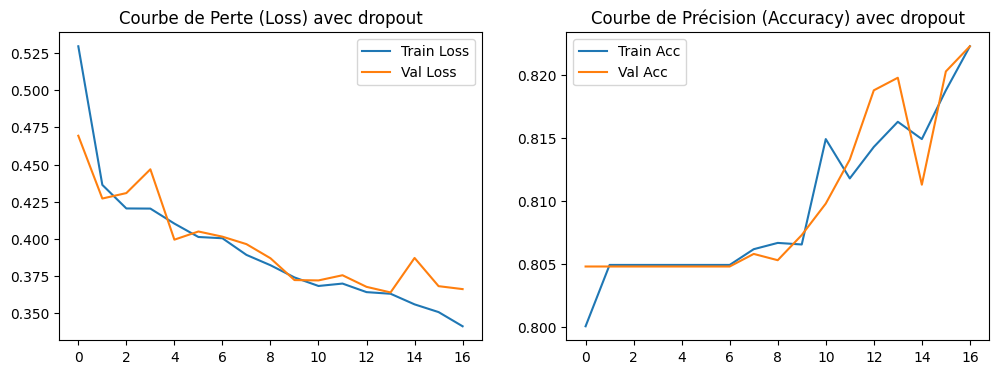

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# --- A. AFFICHAGE DES COURBES ---
plt.figure(figsize=(12, 4))

# Courbe de Loss (Perte)
plt.subplot(1, 2, 1)
plt.plot(history_do.history['loss'], label='Train Loss')
plt.plot(history_do.history['val_loss'], label='Val Loss')
plt.title('Courbe de Perte (Loss) avec dropout')
plt.legend()

# Courbe d'Accuracy (Précision)
plt.subplot(1, 2, 2)
plt.plot(history_do.history['accuracy'], label='Train Acc')
plt.plot(history_do.history['val_accuracy'], label='Val Acc')
plt.title('Courbe de Précision (Accuracy) avec dropout')
plt.legend()

plt.show()

#Rapport

In [17]:
# --- B. GÉNÉRATION DU RAPPORT ---
# 1. Prédire sur les données de test
test_gen.reset()
predictions = model_do.predict(test_gen)
y_pred = (predictions > 0.5).astype(int) # On transforme les probabilités en 0 ou 1
y_true = test_gen.classes

# 2. Afficher le rapport
target_names = ['Bénin', 'Malin']
print("\n--- RAPPORT DE CLASSIFICATION ---")
print(classification_report(y_true, y_pred, target_names=target_names))

63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 197ms/step

--- RAPPORT DE CLASSIFICATION ---
              precision    recall  f1-score   support

       Bénin       0.82      0.99      0.90      1612
       Malin       0.70      0.14      0.23       391

    accuracy                           0.82      2003
   macro avg       0.76      0.56      0.56      2003
weighted avg       0.80      0.82      0.77      2003



#Sauvegarde

In [15]:
# --- E. SAUVEGARDE ---
model_do.save('model_sante_classique.h5')
print("Modèle sauvegardé sous 'model_sante_classique.h5'")

TERMINÉ ! Modèle sauvegardé sous 'model_sante_classique.h5'


In [6]:
# --- C. ON CONSTRUIT LE MODÈLE
model = models.Sequential([
    # 1. Convolution)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)), # Réduction

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)), # Réduction

    # 2. Passage au cerveau
    layers.Flatten(),

    # 3. Le cerveau (Dense) : décide si c'est Malin ou Bénin
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Résultat final (0 à 1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# --- D. ON LANCE L'APPRENTISSAGE ---
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [8]:
from tensorflow.keras.callbacks import EarlyStopping

# early_stop = EarlyStopping(
#     monitor='val_loss',
#     patience=3,
#     restore_best_weights=True
# )

print("Lancement de l'entraînement")
history = model.fit(train_gen, validation_data=test_gen, epochs=30)



Lancement de l'entraînement
Epoch 1/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 74s 275ms/step - accuracy: 0.7992 - loss: 0.4934 - val_accuracy: 0.8048 - val_loss: 0.4462
Epoch 2/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 66s 264ms/step - accuracy: 0.8044 - loss: 0.4362 - val_accuracy: 0.8093 - val_loss: 0.4170
Epoch 3/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 75s 299ms/step - accuracy: 0.8077 - loss: 0.4111 - val_accuracy: 0.8213 - val_loss: 0.4067
Epoch 4/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 65s 261ms/step - accuracy: 0.8130 - loss: 0.4009 - val_accuracy: 0.8213 - val_loss: 0.3949
Epoch 5/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 68s 272ms/step - accuracy: 0.8215 - loss: 0.3798 - val_accuracy: 0.8108 - val_loss: 0.3851
Epoch 6/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 65s 259ms/step - accuracy: 0.8270 - loss: 0.3669 - val_accuracy: 0.8198 - val_loss: 0.4077
Epoch 7/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 65s 260ms/step - accuracy: 0.8313 - loss: 0.3573 - val_accuracy: 0.8183 - val_loss: 0.3873
Epoch 8/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 66s 261ms/step 

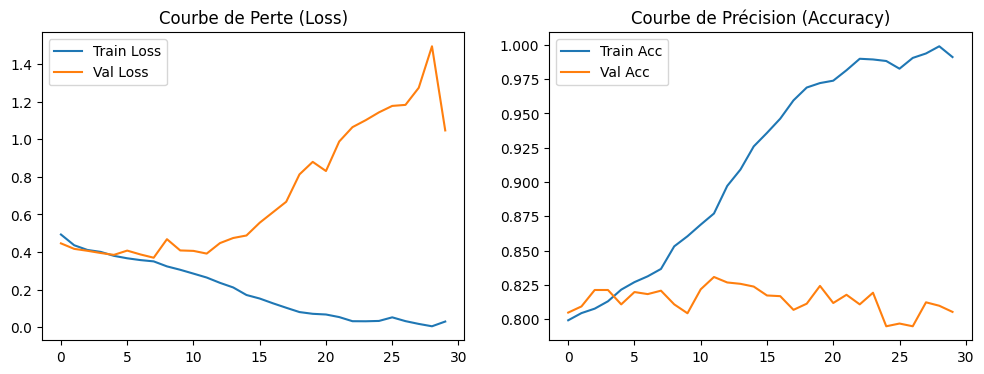

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# --- A. AFFICHAGE DES COURBES ---
plt.figure(figsize=(12, 4))

# Courbe de Loss (Perte)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Courbe de Perte (Loss)')
plt.legend()

# Courbe d'Accuracy (Précision)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Courbe de Précision (Accuracy)')
plt.legend()

plt.show()